# 03 - Feature Importance Analysis

This notebook performs simple feature importance evaluation.

The coefficients from LASSO logistic regression and the SHAP values from an XGBoost model are examined to determine feature importance. Several features have already been excluded due to correlation, interpretability, and domain knowledge considerations rather than feature importance. This notebook serves as a sanity check to confirm whether they are truly unimportant and can be safely excluded.

## Imports

In [1]:
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

from IPython.display import display, HTML

sys.path.append("../src")

from my_datasets import census
from my_datasets import dataframe_utils
import ml_utils
from ml_utils import feature_importance
from ml_utils import evaluation
from ml_utils import model_pipelines
from ml_utils import visualizations

## Helper Functions

### `train_full_model`

Reusable utility function that loads a previously trained model from disk if available. If no saved model exists, it trains a new model using the full dataset, saves it for future reuse, and then returns the fitted model.

In [2]:
def train_full_model(
    model_name,
    df,
    categorical_columns,
    numeric_columns,
    target_column,
    weight_column,
    model_filename_prefix="feature_importance"
):
    filename = f"{model_filename_prefix}-{model_name}.joblib"
    try:
        pipeline = census.load_model(filename)
        print(f"Loaded pretrained {model_name} model.")
    except FileNotFoundError:
        print(f"No pretrained {model_name} model found.")
        model = model_pipelines.get_prediction_models(
        	categorical_columns=categorical_columns,
        	numeric_columns=numeric_columns,
            remove_niu=False,
            select=model_name
        )
        
        import time
        from datetime import timedelta
        
        start = time.perf_counter()
        pipeline = evaluation.fit_model(
        	estimator=model,
        	X=data_df[categorical_columns + numeric_columns],
        	y=data_df[target_column],
        	sample_weight=(
                data_df[weight_column] / data_df[weight_column].mean()
            )
        )
        end = time.perf_counter()
        
        elapsed = end - start
        print(f"  {timedelta(seconds=elapsed)}")
    
        census.save_model(pipeline, filename)

    return pipeline

## Feature Exclusions

I think following features should be excluded based on data quality issues, redundancy, or unclear interpretation:

### Ambiguous or Potentially Noisy Categories
- `hispanic origin` — includes an `All other` category, which may act as a catch all and could mix non Hispanic individuals or heterogeneous groups

### Redundant or Hierarchical Features
- `detailed occupation recode` — subcategory of `major occupation code` already represented at a higher level
- `detailed industry recode` — subcategory of `major industry code` already represented at a higher level

### Unclear Interpretation
- `veterans benefits` — unclear meaning
- `detailed household and family stat` — difficult to interpret and validate semantically

### Sparse / NIU Dominated Features
These features contain a large proportion of NIU values, making them unreliable:
- `family members under 18`
- `region of previous residence`
- `state of previous residence`

### High Number of Missing Values (`?`)
These features contain an extremely high number of missing values represented as `?`:
- `migration code-change in msa`
- `migration code-change in reg`
- `migration code-move within reg`
- `migration prev res in sunbelt`

### Low-Signal Feature
- `year` — this feature takes on limited values and is not expected to contribute meaningful predictive signal

In [3]:
exclude_features = [
    "hispanic origin",
    "detailed occupation recode",
    "detailed industry recode",

    "veterans benefits",
    "detailed household and family stat",

    "family members under 18",
    "region of previous residence",
    "state of previous residence",

    "migration code-change in msa",
    "migration code-change in reg",
    "migration code-move within reg",
    "migration prev res in sunbelt",

    "year"
]

## Data Loading and Inspection

The cleaned, processed dataset is loaded into a dataframe and basic inspection is performed to verify that it has been loaded correctly.

The target and sample weight columns are identified, along with the numeric-categorical features.

In [4]:
data_df = census.load_processed_dataframe("clean_data.csv", header=0)

target_column = census.get_target_feature()
weight_column = census.get_sample_weights_feature()
numeric_categorical_features = census.get_numeric_categorical_features()

# # subsample for code testing
# from sklearn.model_selection import train_test_split
# data_df, _ = train_test_split(
#     data_df,
#     train_size=1000,
#     stratify=data_df[target_column],
#     random_state=42,
# )
# data_df = data_df.reset_index(drop=True)
# dataframe_utils.print_dataframe_info(data_df)

clean_data.csv Memory Usage: 362.04 MB


,dtype,count,non_null,null_count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,int64,199523,199523,0,NaN,NaN,NaN,34.494199,22.310895,0.0,15.0,33.0,50.0,90.0
class of worker,str,199523,199523,0,9,Not in universe,100245,NaN,NaN,NaN,NaN,NaN,NaN,NaN
detailed industry recode,int64,199523,199523,0,NaN,NaN,NaN,15.35232,18.067129,0.0,0.0,0.0,33.0,51.0
detailed occupation recode,int64,199523,199523,0,NaN,NaN,NaN,11.306556,14.454204,0.0,0.0,0.0,26.0,46.0
education,str,199523,199523,0,17,High school graduate,48407,NaN,NaN,NaN,NaN,NaN,NaN,NaN
wage per hour,int64,199523,199523,0,NaN,NaN,NaN,55.426908,274.896454,0.0,0.0,0.0,0.0,9999.0
enroll in edu inst last wk,str,199523,199523,0,3,Not in universe,186943,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital stat,str,199523,199523,0,7,Never married,86485,NaN,NaN,NaN,NaN,NaN,NaN,NaN
major industry code,str,199523,199523,0,24,Not in universe or children,100684,NaN,NaN,NaN,NaN,NaN,NaN,NaN
major occupation code,str,199523,199523,0,15,Not in universe,100684,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,age,class of worker,detailed industry recode,detailed occupation recode,education,wage per hour,enroll in edu inst last wk,marital stat,major industry code,major occupation code,race,hispanic origin,sex,member of a labor union,reason for unemployment,full or part time employment stat,capital gains,capital losses,dividends from stocks,tax filer stat,region of previous residence,state of previous residence,detailed household and family stat,detailed household summary in household,weight,migration code-change in msa,migration code-change in reg,migration code-move within reg,live in this house 1 year ago,migration prev res in sunbelt,num persons worked for employer,family members under 18,country of birth father,country of birth mother,country of birth self,citizenship,own business or self employed,fill inc questionnaire for veteran's admin,veterans benefits,weeks worked in year,year,label
0,73,Not in universe,0,0,High school graduate,0,Not in universe,Widowed,Not in universe or children,Not in universe,White,All other,Female,Not in universe,Not in universe,Not in labor force,0,0,0,Nonfiler,Not in universe,Not in universe,Other Rel 18+ ever marr not in subfamily,Other relative of householder,1700.09,NaN,NaN,NaN,Not in universe under 1 year old,NaN,0,Not in universe,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,95,- 50000.
1,58,Self-employed-not incorporated,4,34,Some college but no degree,0,Not in universe,Divorced,Construction,Precision production craft & repair,White,All other,Male,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Head of household,South,Arkansas,Householder,Householder,1053.55,MSA to MSA,Same county,Same county,No,Yes,1,Not in universe,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,52,94,- 50000.
2,18,Not in universe,0,0,10th grade,0,High school,Never married,Not in universe or children,Not in universe,Asian or Pacific Islander,All other,Female,Not in universe,Not in universe,Not in labor force,0,0,0,Nonfiler,Not in universe,Not in universe,Child 18+ never marr Not in a subfamily,Child 18 or older,991.95,NaN,NaN,NaN,Not in universe under 1 year old,NaN,0,Not in universe,Vietnam,Vietnam,Vietnam,Foreign born- Not a citizen of U S,0,Not in universe,2,0,95,- 50000.
3,9,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,White,All other,Female,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Nonfiler,Not in universe,Not in universe,Child <18 never marr not in subfamily,Child under 18 never married,1758.14,Nonmover,Nonmover,Nonmover,Yes,Not in universe,0,Both parents present,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000.
4,10,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,White,All other,Female,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Nonfiler,Not in universe,Not in universe,Child <18 never marr not in subfamily,Child under 18 never married,1069.16,Nonmover,Nonmover,Nonmover,Yes,Not in universe,0,Both parents present,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199518,87,Not in universe,0,0,7th and 8th grade,0,Not in universe,Married-civilian spouse present,Not in universe or children,Not in universe,White,All other,Male,Not in universe,Not in universe,Not in labor force,0,0,0,Joint both 65+,Not in universe,Not in universe,Householder,Householder,955.27,NaN,NaN,NaN,Not in universe under 1 year old,NaN,0,Not in universe,Canada,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,95,- 50000.
199519,65,Self-employed-incorporated,37,2,11t

## Feature Type Separation and Adjustments

The dataset features are split into categorical and numeric column groups, with additional numeric-categorical features explicitly treated as categorical.

Adjustments are made to ensure correct feature assignment and prevent data leakage. The target column is removed from the categorical feature list, while the sample weight column is removed from the numeric feature list.

In [5]:
categorical_columns, numeric_columns = ml_utils.get_categorical_numeric_split(
    data_df,
    treat_as_categorical=numeric_categorical_features
)

if target_column in categorical_columns:
    categorical_columns.remove(target_column)

if weight_column in numeric_columns:
    numeric_columns.remove(weight_column)

## LASSO Logistic Regression Feature Selection

The LASSO L1 penalty causes many of the model's coefficients to shrink exactly to zero. As a result, features with little predictive value are effectively removed from the model, while more informative features are retained with non-zero weights. This makes LASSO a built-in method for feature selection, especially useful in high-dimensional settings where many predictors may be redundant or weakly informative.

### Train LASSO Logistic Regression Model

A LASSO-regularized logistic regression model is trained on the full feature set and target variable, with sample weights passed to account for population weighting in the data.

In [6]:
lasso_pipeline = train_full_model(
    "lasso_logistic_regression",
    data_df,
    categorical_columns,
    numeric_columns,
    target_column,
    weight_column
)

display(lasso_pipeline)

No pretrained lasso_logistic_regression model found.


/Users/jagraves21/venv/magic/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
2026-06-17 17:18:12,395 - INFO - Saved model to models directory: /Users/jagraves21/notebooks/jpm/census-income-ml-project/data/Census/models/feature_importance-lasso_logistic_regression-2026_06_17-17_18_12.joblib


  0:03:34.623395


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('LogisticRegression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numeric', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the

### Feature Importance from LASSO Model Coefficients

Because categorical features were one-hot encoded, each original feature was represented by multiple model coefficients. To obtain a single importance score for each original feature, the coefficients associated with the same feature were grouped together and aggregated using the L2 norm. This provides a measure of the overall magnitude of a feature's effect on the model while accounting for the contribution of all encoded categories. The L2 norm better captures the overall predictive signal associated with a feature than the mean absolute coefficient, which can dilute the importance of categorical variables with many levels by averaging their coefficients across multiple one-hot encoded categories.

Numeric features correspond to a single model coefficient and can therefore be viewed as a special case of the same calculation, where the L2 norm is simply the absolute value of the coefficient. This approach produces a consistent importance metric across both numeric and categorical features, enabling meaningful comparisons of their relative influence on the model.

In [7]:
raw_importance_df = feature_importance.logistic_regression_importance(lasso_pipeline)
grouped_importance_df = (
	raw_importance_df
	.groupby("feature_name")["coefficient"]
	.agg(
		l2_norm=lambda x: np.sqrt(np.sum(x**2)),
		sum_abs=lambda x: np.sum(np.abs(x)),
		mean_abs=lambda x: np.mean(np.abs(x)),
		std_abs=lambda x: np.std(np.abs(x)),
		count="count"
	)
	.sort_values("l2_norm", ascending=False)
)

display(raw_importance_df)
display(grouped_importance_df)

,feature_raw,feature_type,feature_name,feature_value,coefficient,abs_coefficient,odds_ratio
0,categorical__education_Doctorate degree(PhD EdD),categorical,education,Doctorate degree(PhD EdD),1.952086,1.952086,7.043366
1,categorical__education_Prof school degree (MD ...,categorical,education,Prof school degree (MD DDS DVM LLB JD),1.580860,1.580860,4.859132
2,categorical__tax filer stat_Nonfiler,categorical,tax filer stat,Nonfiler,-1.550161,1.550161,0.212214
3,categorical__education_Masters degree(MA MS ME...,categorical,education,Masters degree(MA MS MEng MEd MSW MBA),1.370577,1.370577,3.937624
4,numeric__weeks worked in year,numeric,weeks worked in year,NaN,1.113628,1.113628,3.045386
...,...,...,...,...,...,...,...
499,categorical__detailed industry recode_50,categorical,detailed industry recode,50,0.000000,0.000000,1.000000
500,categorical__country of birth self_Thailand,categorical,country of birth self,Thailand,0.000000,0.000000,1.000000
501,categorical__country of birth self_Portugal,categorical,country of birth self,Portugal,0.000000,0.000000,1.000000
502,categorical__country of birth self_Yugoslavia,categorical,country of birth self,Yugoslavia,0.000000,0.000000,1.000000


,l2_norm,sum_abs,mean_abs,std_abs,count
feature_name,,,,,
education,3.734194,12.535324,0.737372,0.525861,17
detailed occupation recode,2.513082,13.253263,0.281984,0.234220,47
detailed industry recode,2.124730,11.803316,0.226987,0.187867,52
tax filer stat,1.685265,2.716394,0.452732,0.518060,6
major occupation code,1.558845,4.797452,0.319830,0.244353,15
weeks worked in year,1.113628,1.113628,1.113628,0.000000,1
class of worker,1.097213,2.222287,0.246921,0.269804,9
sex,1.002683,1.090036,0.545018,0.453478,2
country of birth self,0.935587,3.340959,0.079547,0.120471,42


### Feature Importance of Excluded Features from LASSO Model Coefficients

Here, only the features suggested for exclusion are extracted for closer examination.

In [8]:
display(
    grouped_importance_df.loc[
		grouped_importance_df.index.isin(exclude_features)
	]
)

,l2_norm,sum_abs,mean_abs,std_abs,count
feature_name,,,,,
detailed occupation recode,2.513082,13.253263,0.281984,0.234220,47
detailed industry recode,2.124730,11.803316,0.226987,0.187867,52
state of previous residence,0.847996,3.773293,0.075466,0.093203,50
detailed household and family stat,0.732056,1.995590,0.052516,0.106512,38
hispanic origin,0.668416,1.569163,0.174351,0.138722,9
region of previous residence,0.585430,0.915291,0.152548,0.183984,6
migration code-change in msa,0.413204,0.761043,0.084560,0.108721,9
family members under 18,0.408498,0.648696,0.129739,0.128615,5
veterans benefits,0.340051,0.340051,0.340051,0.000000,1


### Visualization of LASSO Feature Importance

The following plot shows feature importance from the LASSO model, with categorical variables aggregated using the L2 norm of their associated one-hot encoded coefficients. Features highlighted in red indicate the predefined set of variables that were flagged for potential exclusion.

Among these, `detailed occupation recode` and `detailed industry recode` rank as the second and third most important features in the model, respectively. This suggests that, despite their initial choice for exclusion, both variables carry substantial predictive signal. In contrast, the remaining flagged features generally rank lower in importance, indicating weaker contributions to model performance.

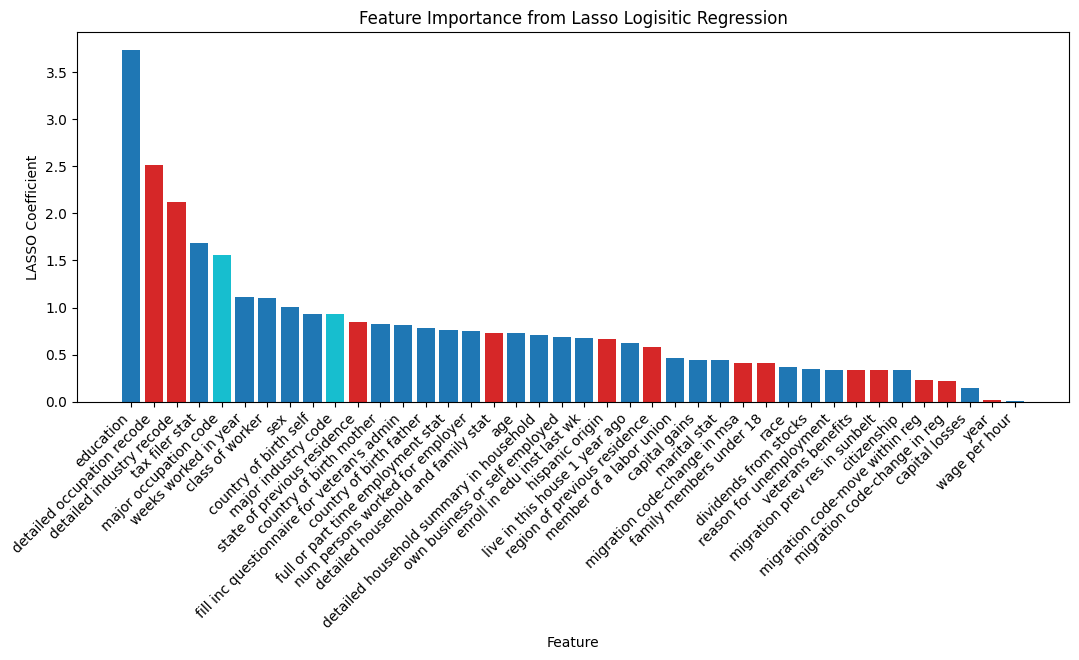

2026-06-17 17:18:13,186 - INFO - Saved figure to figures directory: /Users/jagraves21/notebooks/jpm/census-income-ml-project/data/Census/figures/feature_importance-lasso_logisitic_regression.png


'/Users/jagraves21/notebooks/jpm/census-income-ml-project/data/Census/figures/feature_importance-lasso_logisitic_regression.png'

In [9]:
_,fig,ax = visualizations.bar_plot(
    df=grouped_importance_df,
    data_column="l2_norm",
    figsize=(2*6.4,4.8),
    colors=[
    	"tab:red" if feature in exclude_features
    	else "tab:cyan" if feature in {"major occupation code", "major industry code"}
    	else "tab:blue"
    	for feature in grouped_importance_df.index
    ],
    title="Feature Importance from Lasso Logisitic Regression",
    xlabel="Feature",
    ylabel="LASSO Coefficient",
    return_fig=True
)
plt.show()

census.save_figure(fig, "feature_importance-lasso_logisitic_regression.png")

### Cumulative Feature Coverage from LASSO Feature Importance

This plot orders features by importance using mean absolute LASSO coefficients and shows how many feature dimensions are included as progressively larger subsets are selected. The goal is to identify a reduced set of features that retains most of the model's signal while reducing dimensionality.

The cumulative curve helps highlight where additional features contribute diminishing returns, supporting a more compact feature set.

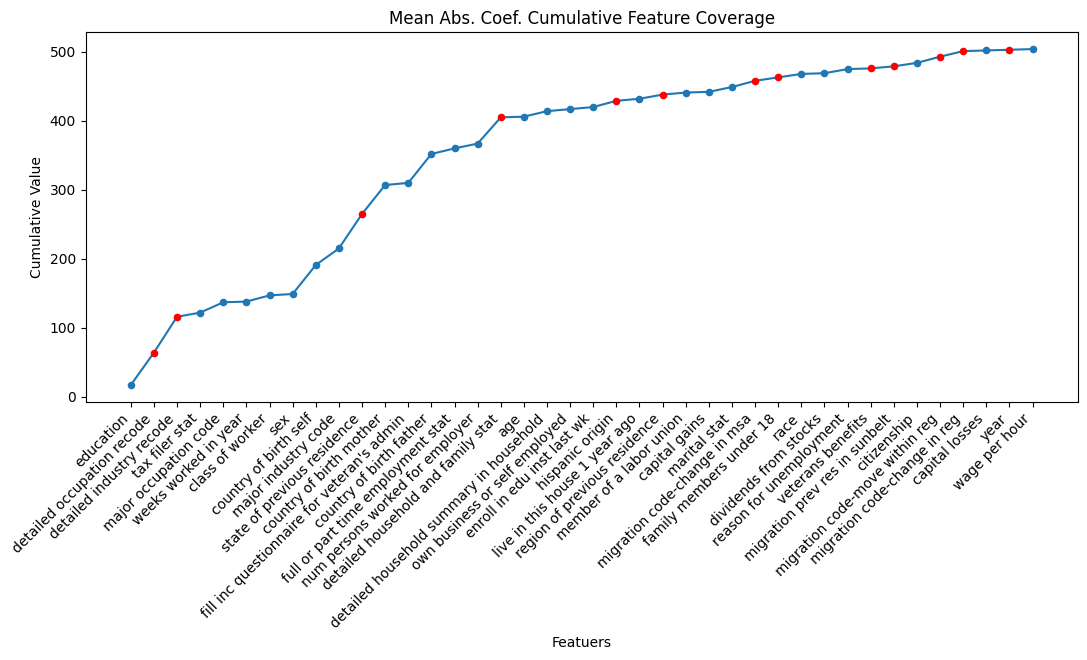

In [10]:
visualizations.plot_cumulative_series(
    grouped_importance_df.sort_values("l2_norm", ascending=False)["count"].cumsum(),
    highlight_labels=exclude_features,
    title="Mean Abs. Coef. Cumulative Feature Coverage",
    figsize=(2*6.4, 4.8)
)

### Feature Importance After Removing Redundant Hierarchical Variables

Following the initial feature importance analysis, `detailed occupation recode` and `detailed industry recode` were removed from the model and the LASSO was refit. This decision was based on the fact that both variables represent finer-grained subcategories of `major occupation code` and `major industry code`, which already capture the broader structure at a higher level of aggregation. The feature importance was then recomputed to assess whether the corresponding higher-level features gain additional importance once their detailed subcategories are excluded.

After this adjustment, `major occupation code` and `major industry code` become the second and third most important features in the model, respectively. This suggests that much of the predictive signal previously attributed to the detailed variables is absorbed by their higher-level counterparts, and that using the aggregated representations may be sufficient for modeling.

No pretrained lasso_logistic_regression model found.


/Users/jagraves21/venv/magic/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
2026-06-17 17:20:03,203 - INFO - Saved model to models directory: /Users/jagraves21/notebooks/jpm/census-income-ml-project/data/Census/models/feature_importance_test-lasso_logistic_regression-2026_06_17-17_20_03.joblib


  0:01:49.712875


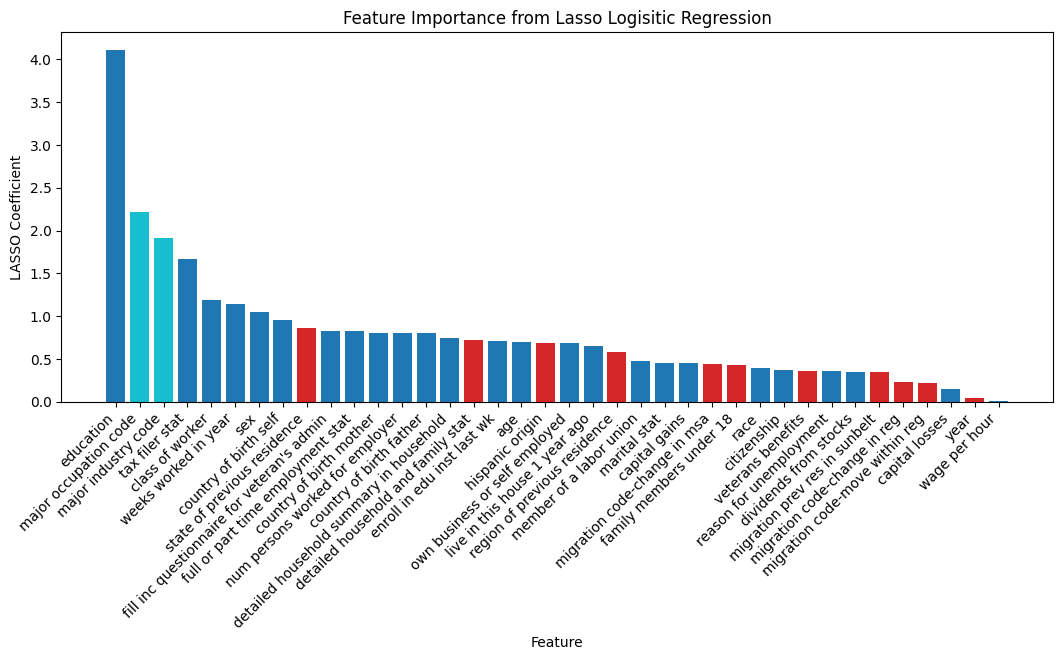

2026-06-17 17:20:03,760 - INFO - Saved figure to figures directory: /Users/jagraves21/notebooks/jpm/census-income-ml-project/data/Census/figures/feature_importance-lasso_logisitic_regression2.png


'/Users/jagraves21/notebooks/jpm/census-income-ml-project/data/Census/figures/feature_importance-lasso_logisitic_regression2.png'

In [11]:
lasso_pipeline = train_full_model(
    "lasso_logistic_regression",
    data_df,
    [c for c in categorical_columns if c not in {"detailed occupation recode", "detailed industry recode"}],
    numeric_columns,
    target_column,
    weight_column,
    model_filename_prefix="feature_importance_test"
)

raw_importance_df = feature_importance.logistic_regression_importance(lasso_pipeline)
grouped_importance_df = (
	raw_importance_df
	.groupby("feature_name")["coefficient"]
	.agg(
		l2_norm=lambda x: np.sqrt(np.sum(x**2)),
		sum_abs=lambda x: np.sum(np.abs(x)),
		mean_abs=lambda x: np.mean(np.abs(x)),
		std_abs=lambda x: np.std(np.abs(x)),
		count="count"
	)
	.sort_values("l2_norm", ascending=False)
)

_,fig,ax = visualizations.bar_plot(
    df=grouped_importance_df,
    data_column="l2_norm",
    figsize=(2*6.4,4.8),
    colors=[
    	"tab:red" if feature in exclude_features
    	else "tab:cyan" if feature in {"major occupation code", "major industry code"}
    	else "tab:blue"
    	for feature in grouped_importance_df.index
    ],
    title="Feature Importance from Lasso Logisitic Regression",
    xlabel="Feature",
    ylabel="LASSO Coefficient",
    return_fig=True
)
plt.show()

census.save_figure(fig, "feature_importance-lasso_logisitic_regression2.png")

## Feature Importance via SHAP (XGBoost)

SHAP (SHapley Additive exPlanations) attempts to explain a models predictions by assigning each feature a contribution value based on its effect on the output. In the context of XGBoost, SHAP values provide a consistent way to quantify feature importance while also capturing feature interactions and non-linear effects.

The resulting SHAP values show that most of the features selected for exclusion rank below many other features in importance.

### Train XGBoost Model

An XGBoost model is trained on the full feature set and target variable, with sample weights passed to account for population weighting in the data.

In [12]:
xgboost_pipeline = train_full_model(
    "xgboost",
    data_df,
    categorical_columns,
    numeric_columns,
    target_column,
    weight_column
)

display(xgboost_pipeline)

No pretrained xgboost model found.


2026-06-17 17:20:27,277 - INFO - Saved model to models directory: /Users/jagraves21/notebooks/jpm/census-income-ml-project/data/Census/models/feature_importance-xgboost-2026_06_17-17_20_27.joblib


  0:00:23.490091


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('XGBStringClassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numeric', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of th

### Feature Importance from SHAP Values (XGBoost)

Each observation in the dataset is assigned a SHAP value for every model feature, representing that feature’s contribution to the prediction for that specific instance. To obtain a global measure of feature importance, the mean absolute SHAP value is computed for each feature. For categorical variables that were one-hot encoded, SHAP values are first calculated at the encoding levels and then aggregated across all corresponding one-hot encoded columns. This produces a single importance score per original categorical feature by combining the contributions of all its encoded categories.

Numeric features correspond to a single model column and therefore a single set of SHAP values. This allows direct comparison between numeric features and the aggregated categorical features within the same mean absolute SHAP importance framework.

In [13]:
raw_importance_df = feature_importance.xgboost_importance(
    xgboost_pipeline, data_df[categorical_columns + numeric_columns]
)
grouped_importance_df = (
    raw_importance_df
    .groupby("feature_name")["mean_abs_shap"]
    .agg(["sum", "mean", "std", "min", "max", "count"])
    .sort_values("mean", ascending=False)
)

display(raw_importance_df)
display(grouped_importance_df)

,feature_raw,feature_type,feature_name,feature_value,mean_abs_shap,mean_shap,positive_ratio
0,numeric__age,numeric,age,NaN,0.863634,-0.590915,0.475690
1,numeric__weeks worked in year,numeric,weeks worked in year,NaN,0.853269,-0.414000,0.391258
2,categorical__tax filer stat_Nonfiler,categorical,tax filer stat,Nonfiler,0.603420,-0.475284,0.623632
3,categorical__sex_Female,categorical,sex,Female,0.244272,-0.079966,0.478837
4,numeric__dividends from stocks,numeric,dividends from stocks,NaN,0.238928,-0.096119,0.103968
...,...,...,...,...,...,...,...
499,categorical__class of worker_Without pay,categorical,class of worker,Without pay,0.000000,0.000000,0.000000
500,categorical__country of birth self_Hong Kong,categorical,country of birth self,Hong Kong,0.000000,0.000000,0.000000
501,categorical__country of birth self_Hungary,categorical,country of birth self,Hungary,0.000000,0.000000,0.000000
502,numeric__year,numeric,year,NaN,0.000000,0.000000,0.000000


,sum,mean,std,min,max,count
feature_name,,,,,,
age,0.863634,0.863634,NaN,0.863634,0.863634,1
weeks worked in year,0.853269,0.853269,NaN,0.853269,0.853269,1
dividends from stocks,0.238928,0.238928,NaN,0.238928,0.238928,1
sex,0.340687,0.170344,0.104550,0.096415,0.244272,2
capital gains,0.137231,0.137231,NaN,0.137231,0.137231,1
tax filer stat,0.658667,0.109778,0.242483,0.000159,0.603420,6
capital losses,0.058841,0.058841,NaN,0.058841,0.058841,1
wage per hour,0.034737,0.034737,NaN,0.034737,0.034737,1
num persons worked for employer,0.218810,0.031259,0.049426,0.000333,0.136407,7


### Feature Importance of Excluded Features from SHAP Values

Here, only the features suggested for exclusion are extracted for closer examination.

In [14]:
display(
    grouped_importance_df.loc[
		grouped_importance_df.index.isin(exclude_features)
	]
)

,sum,mean,std,min,max,count
feature_name,,,,,,
detailed occupation recode,0.181397,0.003860,0.009926,0.0,0.063845,47
hispanic origin,0.029040,0.003227,0.008538,0.0,0.025828,9
detailed industry recode,0.111334,0.002141,0.006242,0.0,0.031883,52
region of previous residence,0.006320,0.001053,0.002116,0.0,0.005323,6
migration code-change in reg,0.006791,0.000849,0.002255,0.0,0.006426,8
detailed household and family stat,0.029579,0.000778,0.002491,0.0,0.012961,38
migration prev res in sunbelt,0.000932,0.000311,0.000402,0.0,0.000765,3
migration code-change in msa,0.002642,0.000294,0.000648,0.0,0.001902,9
state of previous residence,0.001916,0.000038,0.000213,0.0,0.001506,50


### Visualization of SHAP Value (XGBoost) Feature Importance

The following plot aggregates one-hot encoded categorical features back into their original variables and computes summary statistics over the resulting SHAP values.

Feature importance is measured using the magnitude of SHAP values, with higher absolute values indicating a stronger influence on the model’s predictions. This allows categorical features with multiple encoded columns to be evaluated as a single feature, making them directly comparable to numeric features.

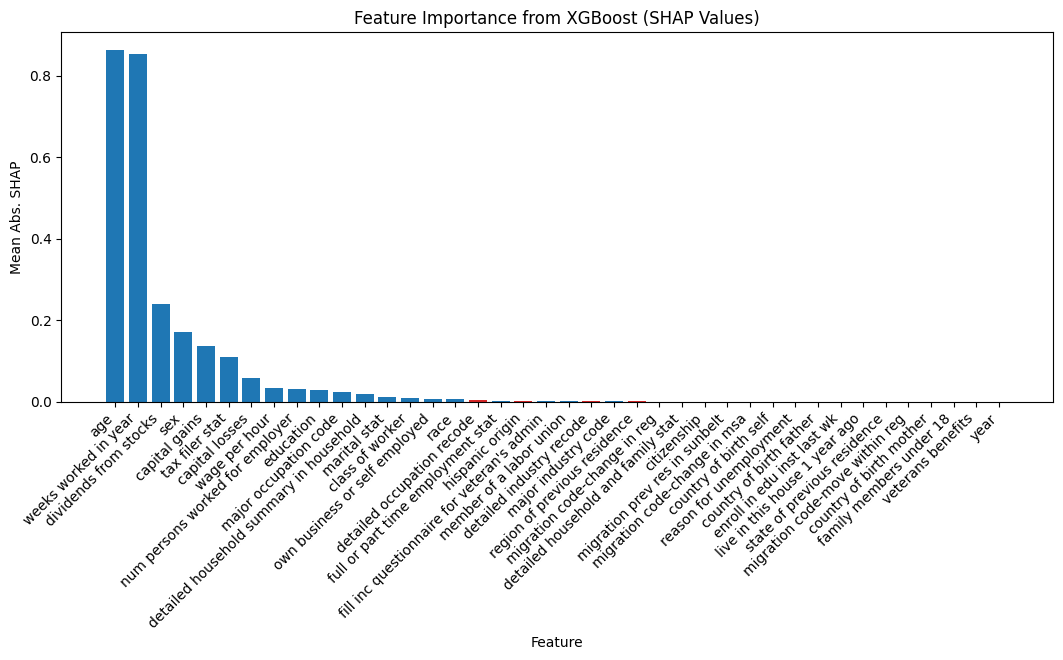

2026-06-17 17:21:09,484 - INFO - Saved figure to figures directory: /Users/jagraves21/notebooks/jpm/census-income-ml-project/data/Census/figures/feature_importance-xgboost.png


'/Users/jagraves21/notebooks/jpm/census-income-ml-project/data/Census/figures/feature_importance-xgboost.png'

In [15]:
_,fig,ax = visualizations.bar_plot(
    df=grouped_importance_df,
    data_column="mean",
    figsize=(2*6.4,4.8),
    colors=[
    	"tab:red" if feature in exclude_features else "tab:blue"
    	for feature in grouped_importance_df.index
    ],
    title="Feature Importance from XGBoost (SHAP Values)",
    xlabel="Feature",
    ylabel="Mean Abs. SHAP",
    return_fig=True
)
plt.show()

census.save_figure(fig, "feature_importance-xgboost.png")

### Cumulative Feature Coverage from SHAP Feature Importance

This plot orders features by their importance, based on mean absolute SHAP values, and tracks how many underlying feature dimensions are covered as increasingly larger subsets are selected.

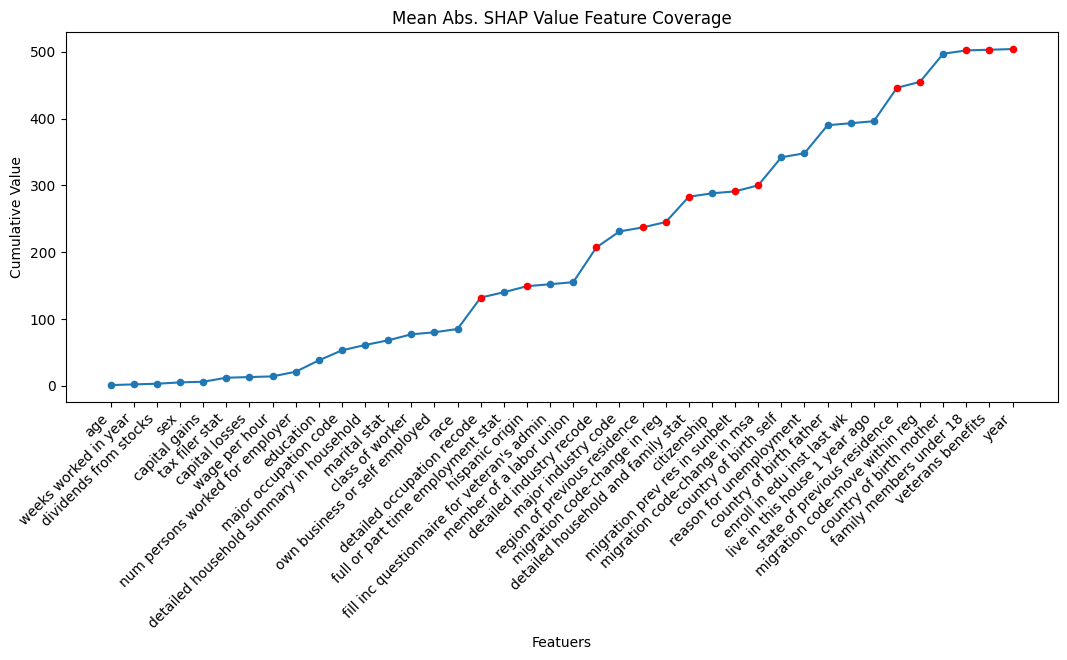

In [16]:
visualizations.plot_cumulative_series(
    grouped_importance_df.sort_values("mean", ascending=False)["count"].cumsum(),
    highlight_labels=exclude_features,
    title="Mean Abs. SHAP Value Feature Coverage",
    figsize=(2*6.4, 4.8)
)